# PPG Cleaning (Preprocessing)

Cleans the green-channel PPG for both devices and writes an EDA-mergeable file.
This stage is **preprocessing only** — no peak detection, HRV, or upsampling
(those belong to feature extraction, run later per segment).

**Input:** `aoi_physio_survey.csv`
**Output:** `aoi_physio_survey_ppg_clean.csv` — same rows, with 4 PPG columns:

| column | meaning |
|---|---|
| `PPG_GRN_C`, `PPG_GRN_IS` | langevin-cleaned signal, **unmasked** |
| `PPG_GRN_C_masked`, `PPG_GRN_IS_masked` | cleaned, with artifact regions set to **NaN** |

- **Cleaning** (langevin bandpass): per recording (ID × Condition), on each
  continuous run of valid samples — never filtered across NaN gaps.
- **Masking** (MAD / Hampel-style, k=8): per contiguous reliability block, so each
  segment (including each separate "No Video" block) gets its own threshold.
- Replay / all-NaN rows pass through untouched.

In [238]:
import pandas as pd
import numpy as np
import neurokit2 as nk
from scipy.ndimage import label as cc_label
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [239]:
# --- Configuration ---
IN_PATH   = "aoi_physio_survey.csv"
OUT_PATH  = "aoi_physio_survey_ppg_clean.csv"

SAMPLING_RATE   = 25                      # Hz
PPG_COLS        = ["PPG_GRN_C", "PPG_GRN_IS"]
ID_COL          = "ID"

MAD_K           = 8                       # artifact threshold (robust SDs from median)
MAD_PAD_S       = 2.0                     # seconds padded around each artifact region
MIN_MASK_BLOCK_S = 5                      # blocks shorter than this are cleaned but not masked
MIN_CLEAN_SAMPLES = 30                    # valid runs shorter than this are left unfiltered

In [240]:
def artifact_mask(clean, k=MAD_K, pad_s=MAD_PAD_S, sr=SAMPLING_RATE):
    """Boolean mask: samples > k robust-SDs (MAD) from the median, grouped into
    events and padded by pad_s seconds. NaN-safe (ignores NaN when estimating spread)."""
    valid = ~np.isnan(clean)
    mask = np.zeros(len(clean), bool)
    if valid.sum() == 0:
        return mask
    v = clean[valid]
    med = np.median(v)
    mad = np.median(np.abs(v - med)) * 1.4826      # robust std estimate
    if mad == 0:
        return mask
    flag = np.zeros(len(clean), bool)
    flag[valid] = np.abs(v - med) > (k * mad)
    lab, n = cc_label(flag)
    pad = int(pad_s * sr)
    for i in range(1, n + 1):
        idx = np.where(lab == i)[0]
        mask[max(0, idx[0] - pad): min(len(clean), idx[-1] + pad + 1)] = True
    return mask


def contiguous_runs(bool_arr):
    """Yield (start, end) index ranges for each run of True in a boolean array."""
    idx = np.where(bool_arr)[0]
    if len(idx) == 0:
        return
    splits = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[idx[0], idx[splits + 1]]
    ends   = np.r_[idx[splits] + 1, idx[-1] + 1]
    for s, e in zip(starts, ends):
        yield s, e


def contiguous_blocks(labels):
    """Yield (start, end) ranges for each run of identical labels (as strings)."""
    labels = np.asarray(labels).astype(str)
    if len(labels) == 0:
        return
    change = np.where(labels[1:] != labels[:-1])[0] + 1
    starts = np.r_[0, change]
    ends   = np.r_[change, len(labels)]
    for s, e in zip(starts, ends):
        yield s, e

In [241]:
df = pd.read_csv(IN_PATH)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} cols")

# locate the reliability/segment column (the one with HH/LL/M)
SEG_COL = None
for c in df.columns:
    if {"HH", "LL", "M"} & set(df[c].dropna().astype(str).unique()):
        SEG_COL = c; break
assert SEG_COL is not None, "Could not find the reliability column (HH/LL/M)."

# group recordings by ID (+ Condition if present) so filtering never crosses sessions
GROUP_COLS = [c for c in [ID_COL, "Condition"] if c in df.columns]

# locate a timestamp column to guarantee rows are in time order (needed for block logic)
TIME_COL = next((c for c in df.columns
                 if c.lower() in ("timestamp", "time", "unix", "unix_time")), None)

sort_cols = GROUP_COLS + ([TIME_COL] if TIME_COL else [])
if sort_cols:
    df = df.sort_values(sort_cols).reset_index(drop=True)

assert all(c in df.columns for c in PPG_COLS), f"Missing PPG columns: {PPG_COLS}"
print(f"Segment column : {SEG_COL!r}")
print(f"Grouping by     : {GROUP_COLS}")
print(f"Time column     : {TIME_COL!r}  (rows sorted for contiguous-block logic)")

Loaded 4,058,617 rows x 80 cols
Segment column : 'Reliability'
Grouping by     : ['ID', 'Condition']
Time column     : 'Time'  (rows sorted for contiguous-block logic)


In [242]:
# initialise output columns
for col in PPG_COLS:
    df[col] = df[col].astype(float)
    df[col + "_masked"] = np.nan

groups = df.groupby(GROUP_COLS, sort=False) if GROUP_COLS else [("all", df)]
print(f"Processing {len(groups) if hasattr(groups,'__len__') else 'all'} recordings...\n")

for gkey, gdf in groups:
    gidx = gdf.index
    seg_labels = df.loc[gidx, SEG_COL].values

    for col in PPG_COLS:
        raw = df.loc[gidx, col].values.astype(float)
        valid = ~np.isnan(raw)

        # 1) langevin clean — each continuous valid run separately (skip NaN gaps)
        cleaned = raw.copy()
        for s, e in contiguous_runs(valid):
            if (e - s) < MIN_CLEAN_SAMPLES:
                continue                                  # too short to filter; leave as-is
            cleaned[s:e] = nk.ppg_clean(raw[s:e], sampling_rate=SAMPLING_RATE,
                                        method="langevin2021")
        df.loc[gidx, col] = cleaned                       # unmasked cleaned column

        # 2) mask per contiguous reliability block
        masked = cleaned.copy()
        for bs, be in contiguous_blocks(seg_labels):
            block = cleaned[bs:be]
            if (~np.isnan(block)).sum() < MIN_MASK_BLOCK_S * SAMPLING_RATE:
                continue                                  # block too short to mask meaningfully
            m = artifact_mask(block)
            blk = block.copy(); blk[m] = np.nan
            masked[bs:be] = blk
        df.loc[gidx, col + "_masked"] = masked            # masked column

    gname = gkey if not isinstance(gkey, tuple) else "_".join(map(str, gkey))
    print(f"  {gname} done")

Processing 52 recordings...

  4_Distrust Priming done
  6_Distrust Priming done
  7_Trust Priming done
  10_Trust Priming done
  12_Trust Priming done
  13_Distrust Priming done
  14_Trust Priming done
  15_Distrust Priming done
  16_Trust Priming done
  17_Distrust Priming done
  18_Trust Priming done
  19_Distrust Priming done
  20_Trust Priming done
  21_Distrust Priming done
  22_Trust Priming done
  23_Distrust Priming done
  24_Trust Priming done
  25_Distrust Priming done
  26_Trust Priming done
  27_Distrust Priming done
  28_Trust Priming done
  29_Distrust Priming done
  30_Trust Priming done
  31_Distrust Priming done
  32_Trust Priming done
  33_Distrust Priming done
  34_Trust Priming done
  35_Distrust Priming done
  36_Trust Priming done
  37_Distrust Priming done
  38_Trust Priming done
  39_Distrust Priming done
  40_Trust Priming done
  41_Distrust Priming done
  42_Trust Priming done
  43_Distrust Priming done
  44_Trust Priming done
  45_Trust Priming done
  46_Tru

In [243]:
df.to_csv(OUT_PATH, index=False)
print(f"Saved -> {OUT_PATH}  ({df.shape[0]:,} rows x {df.shape[1]} cols)")
print(f"PPG columns now: {[c for c in df.columns if c.startswith('PPG_GRN')]}")

Saved -> aoi_physio_survey_ppg_clean.csv  (4,058,617 rows x 82 cols)
PPG columns now: ['PPG_GRN_C', 'PPG_GRN_IS', 'PPG_GRN_C_masked', 'PPG_GRN_IS_masked']


In [244]:
rows = []
for gkey, gdf in (df.groupby(GROUP_COLS, sort=False) if GROUP_COLS else [("all", df)]):
    gname = gkey if not isinstance(gkey, tuple) else "_".join(map(str, gkey))
    for col in PPG_COLS:
        clean_col = gdf[col]; mask_col = gdf[col + "_masked"]
        n_valid  = clean_col.notna().sum()
        n_masked = (clean_col.notna() & mask_col.isna()).sum()   # was valid, now NaN
        if n_valid:
            rows.append(dict(group=gname, channel=col,
                             valid_s=round(n_valid / SAMPLING_RATE),
                             masked_s=round(n_masked / SAMPLING_RATE),
                             pct_masked=round(100 * n_masked / n_valid, 1)))

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print(f"\nMedian % masked: {summary['pct_masked'].median():.1f}%   "
      f"max {summary['pct_masked'].max():.1f}%")
print("\nHighest-masking streams (worth a visual check):")
print(summary.sort_values('pct_masked', ascending=False).head(8).to_string(index=False))

              group    channel  valid_s  masked_s  pct_masked
 4_Distrust Priming  PPG_GRN_C     2831       632        22.3
 4_Distrust Priming PPG_GRN_IS     2831       330        11.6
 6_Distrust Priming  PPG_GRN_C     3127        41         1.3
 6_Distrust Priming PPG_GRN_IS     3127       101         3.2
    7_Trust Priming  PPG_GRN_C     6333      1325        20.9
    7_Trust Priming PPG_GRN_IS     6333      1686        26.6
   10_Trust Priming  PPG_GRN_C     3441       514        14.9
   10_Trust Priming PPG_GRN_IS     3441      1274        37.0
   12_Trust Priming  PPG_GRN_C     4447         9         0.2
   12_Trust Priming PPG_GRN_IS     4447         0         0.0
13_Distrust Priming  PPG_GRN_C     1392        83         6.0
13_Distrust Priming PPG_GRN_IS     1392       103         7.4
   14_Trust Priming  PPG_GRN_C     2913       538        18.5
   14_Trust Priming PPG_GRN_IS     2913       328        11.3
15_Distrust Priming  PPG_GRN_C     3260       521        16.0
15_Distr

## Verify: cleaned vs. cleaned-masked

Plots one recording's two columns over a window so you can confirm the masked
column is NaN-ing genuine artifacts (gaps) and leaving real pulse intact.

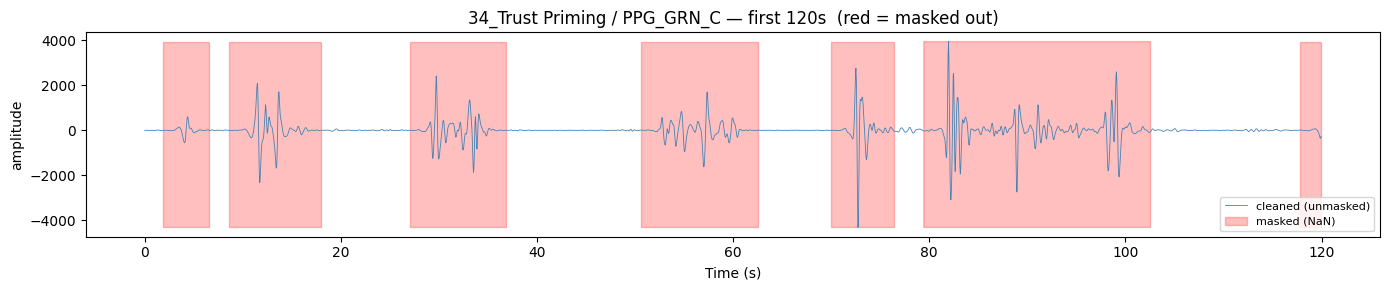

In [245]:
CHECK_GROUP = summary.sort_values('pct_masked', ascending=False).iloc[0]['group']  # the worst masker
CHECK_COL   = "PPG_GRN_C"
WINDOW_S    = 120

# recover that group's rows
if GROUP_COLS:
    mask = pd.Series(True, index=df.index)
    for col, val in zip(GROUP_COLS, str(CHECK_GROUP).split("_")):
        mask &= df[col].astype(str) == val
    gdf = df[mask]
else:
    gdf = df

clean = gdf[CHECK_COL].values
maskd = gdf[CHECK_COL + "_masked"].values
n = min(WINDOW_S * SAMPLING_RATE, len(clean))
t = np.arange(n) / SAMPLING_RATE

plt.figure(figsize=(14, 3))
plt.plot(t, clean[:n], color="steelblue", lw=0.6, label="cleaned (unmasked)")
removed = ~np.isnan(clean[:n]) & np.isnan(maskd[:n])
plt.fill_between(t, np.nanmin(clean[:n]), np.nanmax(clean[:n]),
                 where=removed, color="red", alpha=0.25, label="masked (NaN)")
plt.title(f"{CHECK_GROUP} / {CHECK_COL} — first {WINDOW_S}s  (red = masked out)")
plt.xlabel("Time (s)"); plt.ylabel("amplitude"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()